In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv('/content/sales.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4822 entries, 0 to 4821
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         4822 non-null   int64  
 1   Order ID       4822 non-null   object 
 2   Order Date     4822 non-null   object 
 3   Ship Date      4822 non-null   object 
 4   Ship Mode      4822 non-null   object 
 5   Customer ID    4822 non-null   object 
 6   Customer Name  4822 non-null   object 
 7   Segment        4822 non-null   object 
 8   Country        4822 non-null   object 
 9   City           4822 non-null   object 
 10  State          4822 non-null   object 
 11  Postal Code    4821 non-null   float64
 12  Region         4822 non-null   object 
 13  Product ID     4822 non-null   object 
 14  Category       4822 non-null   object 
 15  Sub-Category   4822 non-null   object 
 16  Product Name   4822 non-null   object 
 17  Sales          4822 non-null   float64
dtypes: float

In [4]:
df.describe()

,Row ID,Postal Code,Sales
count,4822.000000,4821.000000,4822.000000
mean,2411.500000,54907.867040,229.168572
std,1392.135829,31816.476215,637.194491
min,1.000000,1040.000000,0.444000
25%,1206.250000,22304.000000,16.768000
50%,2411.500000,55122.000000,52.596000
75%,3616.750000,90004.000000,212.033500
max,4822.000000,99207.000000,22638.480000


In [5]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
df = df.dropna()

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y", at position 4. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [10]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [12]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

In [13]:
df[['Order Date','Year','Month','Day']].head()

,Order Date,Year,Month,Day
0,2017-11-08,2017,11,8
1,2017-11-08,2017,11,8
2,2017-06-12,2017,6,12
3,2016-10-11,2016,10,11
4,2016-10-11,2016,10,11


In [14]:
X = df[['Year','Month','Day']]
y = df['Sales']

In [16]:
df[['Order Date','Year','Month','Day']].head()

,Order Date,Year,Month,Day
0,2017-11-08,2017,11,8
1,2017-11-08,2017,11,8
2,2017-06-12,2017,6,12
3,2016-10-11,2016,10,11
4,2016-10-11,2016,10,11


In [17]:
monthly_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

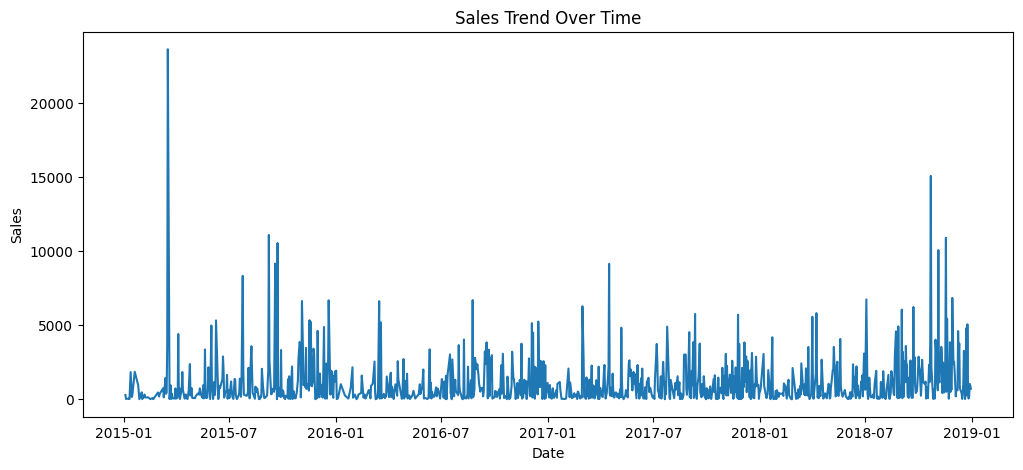

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [19]:
X = df[['Year','Month','Day']]
y = df['Sales']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
predictions = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 272.15995771522927


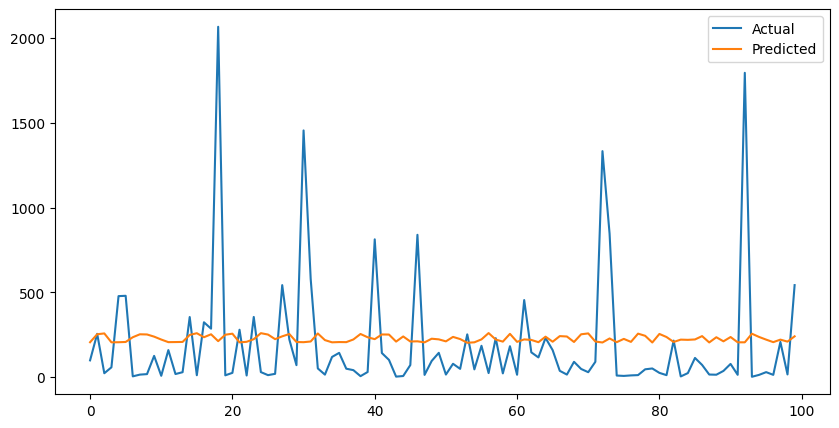

In [24]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')
plt.legend()
plt.show()

In [25]:
future = pd.DataFrame({
    'Year':[2026],
    'Month':[7],
    'Day':[1]
})

forecast = model.predict(future)

print("Forecasted Sales:", forecast[0])

Forecasted Sales: 79.1225920494253
